In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 10,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 10,
                     'lmax': 1500}

use_obs  = ['GC','WL']
choice='alpha_M'

In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 
#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}


camb_path = '/users/chiaradeleo/Desktop/myeftcamb-main/' 


In [5]:
distributions = np.load('./mock_data/MG_test_galonly_IApoly_source_distribution.npy',allow_pickle=True).item()


In [6]:
if 'GC' in distributions:
    Nbins_gc=distributions['GC']['Nbins']

if 'WL' in distributions:
    Nbins_wl=distributions['WL']['Nbins']
if Nbins_gc>=Nbins_wl:
    bincolors = sb.color_palette('hls',Nbins_gc)

else:
    bincolors = sb.color_palette('hls',Nbins_wl)

In [7]:
from source_code.compute_obs_sources import get_obs
case='simple'


In [8]:
choice='alpha'

In [9]:

if choice=='alpha':
    
    stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    'feedback_level':10
                    }
    EFT_params = {'EFTflag': 2, 'AltParEFTmodel': 1, 'EFTCAMB_turn_on_time': 4.01,
                         'RPHmassPmodel': 1,  'RPHmassP0': 1.0,  }
    EFT_params2 = {'EFTflag': 2, 'AltParEFTmodel': 1, 
                         'EFTCAMB_turn_on_time': 4.01,
                         'RPHmassPmodel': 1,  'RPHmassP0': 5.0,  }
     
    
    EFT_params.update(stability_flag)
    EFT_params2.update(stability_flag)
    

In [10]:
if choice=='alpha':
    calc_obs_alpha = get_obs(fiducial,EFT_params,distributions,ells,camb_path,case,feedback=True)
    calc_obs_alpha2 = get_obs(fiducial,EFT_params2,distributions,ells,camb_path,case,feedback=True)
        #print(alpha_M[i])

***************************************************************
 EFTCAMB Return to GR time:        0.4010E+01
 EFTCAMB Return to GR threshold:   0.1000E-07
 Warning, RGR time and turn on time coincide.
 The model might be far from GR at initial time.

 EFT functions at RGR time: 
   OmegaV       =    0.1000E+01
   EFTLambda    =    0.1019E-06
   EFTGamma1V   =    0.3722E-02
   EFTGamma1P   =    0.2785E-02
***************************************************************
 EFTCAMB: checking stability of the theory

 EFTCAMB: theory stable
***************************************************************
CAMB took 7.49 s
Cls packing took 0.05 s
Cls computed in 7.6 s
***************************************************************
 EFTCAMB Return to GR time:        0.4010E+01
 EFTCAMB Return to GR threshold:   0.1000E-07
 Warning, RGR time and turn on time coincide.
 The model might be far from GR at initial time.

 EFT functions at RGR time: 
   OmegaV       =    0.5000E+01
   EFTLambda    =  

In [11]:
#print(calc_obs_alpha2.Cls-calc_obs_alpha.Cls)

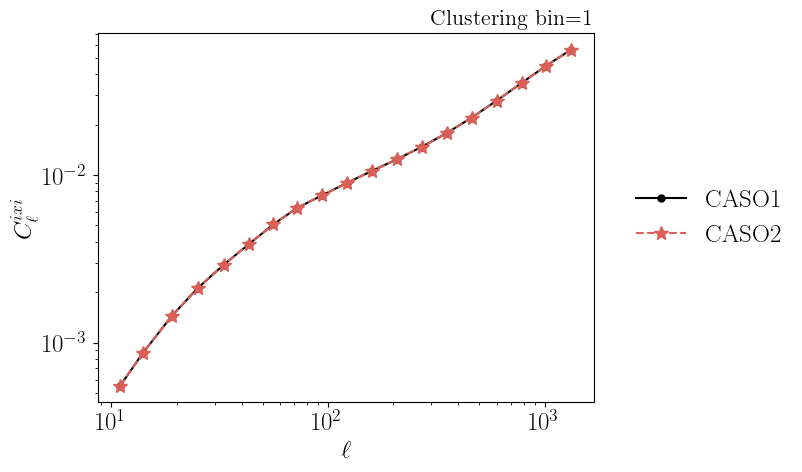

In [12]:
from matplotlib.ticker import LogFormatterSciNotation

if choice=='alpha':
    norm = ells * (ells + 1) / (2 * np.pi)
    for i in range(1,2):  # Loop through the range of cases
        if 'GC' in use_obs:
            plt.title('Clustering bin={}'.format(i), loc='right', fontdict={'fontsize': 16})
            plt.plot(ells, calc_obs_alpha.Cls['G{}xG{}'.format(i, i)] * norm,
                        label=r'CASO1',
                         color='black',
                         marker='o',  # Use different markers for each line
                         linestyle='-', markersize=5)  
            plt.plot(ells, calc_obs_alpha2.Cls['G{}xG{}'.format(i, i)] * norm,
                         label=r'CASO2',
                         color=bincolors[i-1],
                         marker='*',  # Use different markers for each line
                         linestyle='--', markersize=10) # Customize marker size if needed
                #print(EFT_alpha_M[i])
            plt.xlabel(r'$\ell$')
            plt.yscale('log')
            plt.xscale('log')
            plt.gca().yaxis.set_major_formatter(LogFormatterSciNotation())
            plt.ylabel(r'$C_\ell^{ixi}$')
    
    plt.legend(**sidelegend)  # Add a legend to distinguish the lines
    plt.show()

In [13]:
camb_path = '/users/chiaradeleo/Desktop/myeftcamb-main/' 
sys.path.insert(0,camb_path)

import camb
print(camb.__path__)
from camb import model, initialpower
model_key = ['EFT_params','EFT_params2'] 
model_par = [EFT_params, EFT_params2]
model = dict(zip(model_key,model_par))

['/users/chiaradeleo/Desktop/myeftcamb-main/camb']


In [14]:

toplot_totCL = []
lab = []

for key in model:
# We set here camb default param values (Planck 2018 cosmology) through the CAMBparams() method     
# The cosmological model can be changed with CAMB dedicated function
    pars = camb.set_params(H0=67.3,**model[key])

    #pars.set_cosmology(H0=67.3,**model[key]) # H0 (or theta) must be set explicitely here

    results = camb.get_results(pars)
    lab.append(pars.EFTCAMB.model_name()) # store the model names for the model passed to set_cosmology
    powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')
    
    totCL=powers['total']
    unlensedCL=powers['unlensed_scalar']
    toplot_totCL.append(totCL)

***************************************************************
 EFTCAMB Return to GR time:        0.4010E+01
 EFTCAMB Return to GR threshold:   0.1000E-07
 Warning, RGR time and turn on time coincide.
 The model might be far from GR at initial time.

 EFT functions at RGR time: 
   OmegaV       =    0.1000E+01
   EFTLambda    =    0.1036E-06
   EFTGamma1V   =    0.3663E-02
   EFTGamma1P   =    0.2741E-02
***************************************************************
 EFTCAMB: checking stability of the theory

 EFTCAMB: theory stable
***************************************************************
***************************************************************
 EFTCAMB Return to GR time:        0.4010E+01
 EFTCAMB Return to GR threshold:   0.1000E-07
 Warning, RGR time and turn on time coincide.
 The model might be far from GR at initial time.

 EFT functions at RGR time: 
   OmegaV       =    0.1000E+01
   EFTLambda    =    0.1036E-06
   EFTGamma1V   =    0.3663E-02
   EFTGamma1P   = 

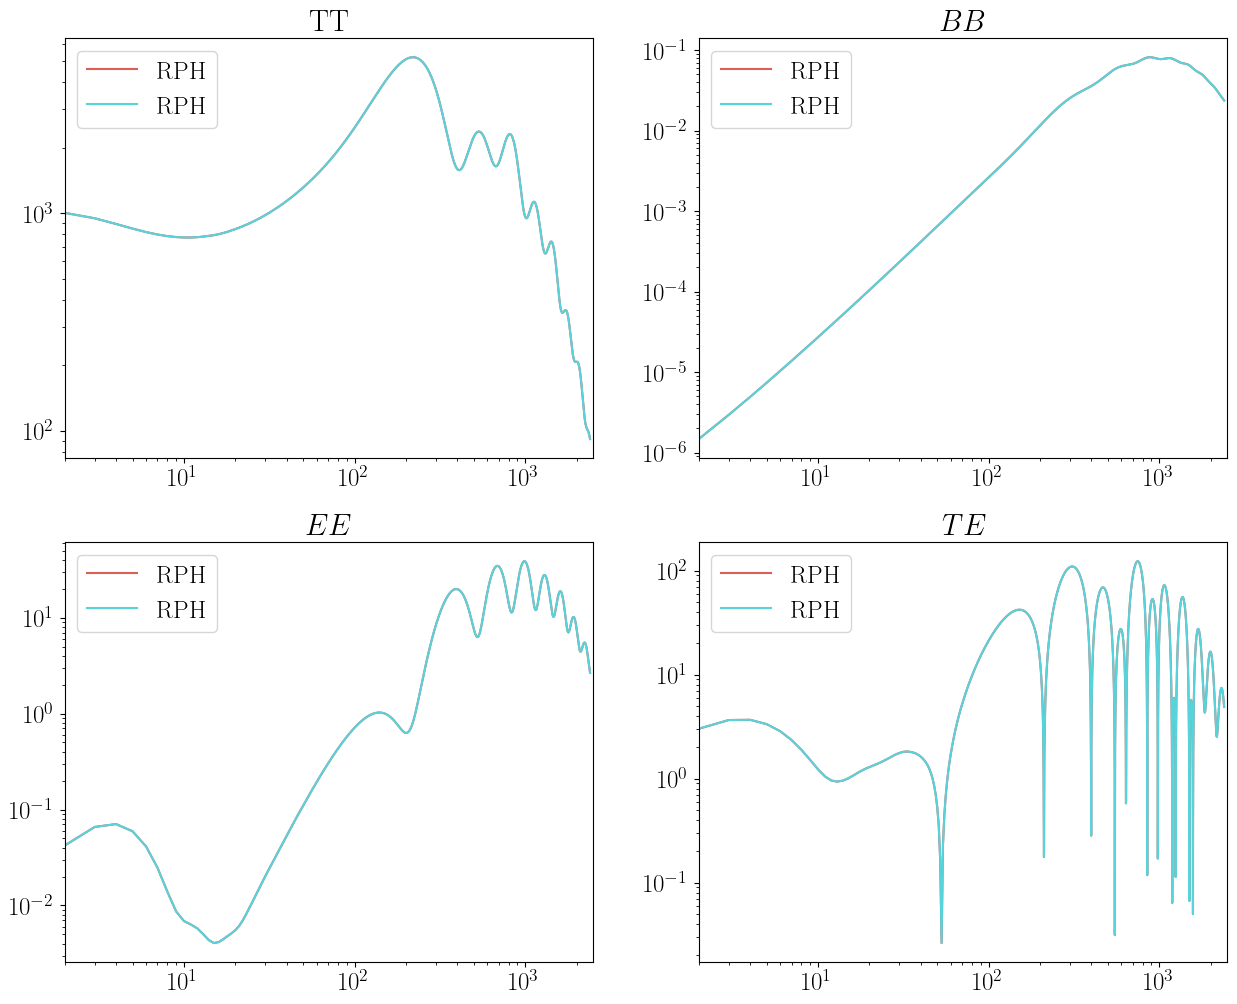

In [15]:
#Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
#The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results)
import seaborn as sns
fig, ax = plt.subplots(2,2, figsize = (15,12))
color = sns.hls_palette(len(model))

for CLS,c,lab in zip(toplot_totCL,color,lab):
    
    ls = np.arange(CLS.shape[0])
    ax[0,0].loglog(ls,CLS[:,0], color=c,label=lab)
    ax[0,1].loglog(ls,CLS[:,2], color=c,label=lab)
    ax[1,0].loglog(ls,CLS[:,1], color=c,label=lab)
    ax[1,1].loglog(ls,abs(CLS[:,3]), color=c,label=lab)
    ax[0,0].set_title('TT')
    ax[0,1].set_title(r'$BB$')
    ax[1,0].set_title(r'$EE$')
    ax[1,1].set_title(r'$TE$');

ax[1,0].legend()
ax[0,0].legend()
ax[0,1].legend()
ax[1,1].legend()

for ax in ax.reshape(-1): ax.set_xlim([2,2500]);